In [ ]:
import pandas as pd
import numpy as np

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import KBinsDiscretizer
import warnings
warnings.filterwarnings('ignore')



In [ ]:
df = pd.read_csv("/content/DM1_game_dataset_module.01.csv")

print(df.shape)
df.head()


(21925, 42)


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,1.609438,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,1.791759,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,1.791759,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,1.098612,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,1.609438,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [ ]:
selected_cols = [
    "GameWeight",
    "NumUserRatings",
    "NumOwned",
    "YearPublished",
    "LanguageEase",
    "Kickstarted",
    "Rating"
]

pm_df = df[selected_cols].copy()

pm_df.head()


,GameWeight,NumUserRatings,NumOwned,YearPublished,LanguageEase,Kickstarted,Rating
0,1.8333,164,528,2014,213.0,0,Low
1,1.0000,38,72,2021,36.0,0,Medium
2,3.6667,231,834,2020,138.0,0,High
3,1.3077,81,154,2004,138.0,0,Low
4,1.5000,79,208,2019,7.0,0,Medium


In [ ]:
pm_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GameWeight      21925 non-null  float64
 1   NumUserRatings  21925 non-null  int64  
 2   NumOwned        21925 non-null  int64  
 3   YearPublished   21925 non-null  int64  
 4   LanguageEase    21925 non-null  float64
 5   Kickstarted     21925 non-null  int64  
 6   Rating          21925 non-null  object 
dtypes: float64(2), int64(4), object(1)
memory usage: 1.2+ MB


In [ ]:
pm_df.isna().sum()


,0
GameWeight,0
NumUserRatings,0
NumOwned,0
YearPublished,0
LanguageEase,0
Kickstarted,0
Rating,0


Feature Selection

We selected a compact set of features capturing game complexity, popularity, accessibility, and temporal aspects.
Numeric variables were retained for discretization, while categorical and binary attributes were chosen to enable interpretable association rule mining.
Features causing redundancy or sparsity were intentionally excluded to avoid trivial or unstable patterns.

In [ ]:
def quantile_binning(series, labels):
    return pd.qcut(series, q=len(labels), labels=labels)


In [ ]:
binned_df = pd.DataFrame()

binned_df["Weight"] = quantile_binning(
    pm_df["GameWeight"],
    ["Light", "Medium", "Heavy"]
)

binned_df["UserRatings"] = quantile_binning(
    pm_df["NumUserRatings"],
    ["Low", "Medium", "High"]
)

binned_df["Owned"] = quantile_binning(
    pm_df["NumOwned"],
    ["Low", "Medium", "High"]
)

binned_df["Year"] = quantile_binning(
    pm_df["YearPublished"],
    ["Old", "Mid", "Recent"]
)

binned_df["Language"] = quantile_binning(
    pm_df["LanguageEase"],
    ["Hard", "Medium", "Easy"]
)


In [ ]:
binned_df["Kickstarted"] = pm_df["Kickstarted"].map({0: "No", 1: "Yes"})
binned_df["Rating"] = pm_df["Rating"]


In [ ]:
binned_df.head()


,Weight,UserRatings,Owned,Year,Language,Kickstarted,Rating
0,Medium,Medium,Medium,Mid,Easy,No,Low
1,Light,Low,Low,Recent,Hard,No,Medium
2,Heavy,Medium,High,Recent,Medium,No,High
3,Light,Medium,Low,Old,Medium,No,Low
4,Light,Medium,Medium,Recent,Hard,No,Medium


In [ ]:
for col in binned_df.columns:
    print(col)
    print(binned_df[col].value_counts())
    print("-" * 40)


Weight
Weight
Medium    7311
Light     7308
Heavy     7306
Name: count, dtype: int64
----------------------------------------
UserRatings
UserRatings
Low       7373
High      7299
Medium    7253
Name: count, dtype: int64
----------------------------------------
Owned
Owned
Low       7337
High      7302
Medium    7286
Name: count, dtype: int64
----------------------------------------
Year
Year
Old       7641
Mid       7367
Recent    6917
Name: count, dtype: int64
----------------------------------------
Language
Language
Hard      7316
Easy      7309
Medium    7300
Name: count, dtype: int64
----------------------------------------
Kickstarted
Kickstarted
No     18563
Yes     3362
Name: count, dtype: int64
----------------------------------------
Rating
Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64
----------------------------------------


Continuous variables were discretized into ordinal categories using quantile-based binning in order to obtain balanced item distributions.
This transformation enables transaction-based pattern mining while preserving relative ordering information.

In [ ]:
transactions = []

for _, row in binned_df.iterrows():
    transaction = []
    for col in binned_df.columns:
        transaction.append(f"{col}={row[col]}")
    transactions.append(transaction)


In [ ]:
transactions[:3]


[['Weight=Medium',
  'UserRatings=Medium',
  'Owned=Medium',
  'Year=Mid',
  'Language=Easy',
  'Kickstarted=No',
  'Rating=Low'],
 ['Weight=Light',
  'UserRatings=Low',
  'Owned=Low',
  'Year=Recent',
  'Language=Hard',
  'Kickstarted=No',
  'Rating=Medium'],
 ['Weight=Heavy',
  'UserRatings=Medium',
  'Owned=High',
  'Year=Recent',
  'Language=Medium',
  'Kickstarted=No',
  'Rating=High']]

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)


In [ ]:
te_df.head()


,Kickstarted=No,Kickstarted=Yes,Language=Easy,Language=Hard,Language=Medium,Owned=High,Owned=Low,Owned=Medium,Rating=High,Rating=Low,Rating=Medium,UserRatings=High,UserRatings=Low,UserRatings=Medium,Weight=Heavy,Weight=Light,Weight=Medium,Year=Mid,Year=Old,Year=Recent
0,True,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,True,True,False,False
1,True,False,False,True,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,True
2,True,False,False,False,True,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True
3,True,False,False,False,True,False,True,False,False,True,False,False,False,True,False,True,False,False,True,False
4,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True


Transaction construction

Each game was transformed into a transaction composed of categorical items derived from discretized numerical attributes, binary indicators, and the target rating.
The resulting dataset was encoded using one-hot representation to enable frequent itemset mining.

In [ ]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    te_df,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()


,support,itemsets
0,0.846659,(Kickstarted=No)
1,0.153341,(Kickstarted=Yes)
2,0.333364,(Language=Easy)
3,0.333683,(Language=Hard)
4,0.332953,(Language=Medium)


In [ ]:
frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets.head(10)


,support,itemsets
0,0.846659,(Kickstarted=No)
10,0.439863,(Rating=Medium)
28,0.371448,"(Kickstarted=No, Rating=Medium)"
18,0.348506,(Year=Old)
36,0.346135,"(Kickstarted=No, Year=Old)"
12,0.336283,(UserRatings=Low)
17,0.336009,(Year=Mid)
6,0.334641,(Owned=Low)
3,0.333683,(Language=Hard)
16,0.333455,(Weight=Medium)


The Apriori algorithm was applied to the transaction dataset to extract frequent itemsets.
A minimum support threshold of 2% was selected to balance coverage and interpretability, ensuring that discovered patterns are sufficiently representative of the dataset.

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7
)

rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Rating=Medium),(Kickstarted=No),0.439863,0.846659,0.371448,0.844463,0.997406,1.0,-0.000966,0.985880,-0.004621,0.405921,-0.014322,0.641593
1,(Year=Old),(Kickstarted=No),0.348506,0.846659,0.346135,0.993195,1.173075,1.0,0.051069,22.532271,0.226464,0.407682,0.955619,0.701009
2,(Rating=Low),(Kickstarted=No),0.330445,0.846659,0.306910,0.928778,1.096992,1.0,0.027136,2.153014,0.132053,0.352691,0.535535,0.645637
3,(Weight=Light),(Kickstarted=No),0.333318,0.846659,0.300661,0.902025,1.065394,1.0,0.018455,1.565106,0.092068,0.341926,0.361065,0.628570
4,(UserRatings=High),(Owned=High),0.332908,0.333044,0.300296,0.902041,2.708471,1.0,0.189423,6.808543,0.945578,0.821255,0.853126,0.901856


In [ ]:
rules = rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

rules.head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1502,"(Kickstarted=No, Rating=Low, Language=Hard, Ow...","(UserRatings=High, Year=Old)",0.029190,0.102121,0.021847,0.748437,7.328938,1.0,0.018866,3.569209,0.889520,0.199583,0.719826,0.481186
1507,"(Rating=Low, Language=Hard, Owned=High)","(Kickstarted=No, UserRatings=High, Year=Old)",0.030422,0.100570,0.021847,0.718141,7.140698,1.0,0.018788,3.191062,0.886940,0.200167,0.686625,0.467687
1491,"(Rating=Low, Language=Hard, Owned=High)","(UserRatings=High, Year=Old)",0.030422,0.102121,0.021984,0.722639,7.076308,1.0,0.018877,3.237218,0.885626,0.198845,0.691093,0.468957
1183,"(Year=Recent, Language=Hard, Owned=High)","(UserRatings=High, Rating=High)",0.037902,0.105906,0.026636,0.702768,6.635738,1.0,0.022622,3.008064,0.882759,0.227326,0.667560,0.477138
850,"(UserRatings=High, Weight=Heavy, Year=Recent)","(Rating=High, Owned=High)",0.044971,0.112702,0.033432,0.743408,6.596202,1.0,0.028364,3.458006,0.888348,0.269090,0.710816,0.520024
1385,"(Kickstarted=Yes, Rating=High, Owned=High)","(UserRatings=High, Year=Recent)",0.033113,0.107822,0.023216,0.701102,6.502394,1.0,0.019645,2.984890,0.875191,0.197210,0.664979,0.458207
1386,"(UserRatings=High, Kickstarted=Yes, Rating=High)","(Year=Recent, Owned=High)",0.031380,0.115530,0.023216,0.739826,6.403741,1.0,0.019590,3.399526,0.871179,0.187684,0.705841,0.470387
1185,"(UserRatings=High, Language=Hard, Year=Recent)","(Rating=High, Owned=High)",0.037400,0.112702,0.026636,0.712195,6.319255,1.0,0.022421,3.082983,0.874458,0.215737,0.675639,0.474268
1598,"(Language=Medium, Weight=Light, UserRatings=Lo...","(Kickstarted=No, Rating=Low, Owned=Low)",0.026043,0.141391,0.020661,0.793345,5.610997,1.0,0.016979,4.154794,0.843753,0.140771,0.759314,0.469737
793,"(Weight=Light, UserRatings=Low, Year=Old)","(Kickstarted=No, Rating=Low, Owned=Low)",0.045747,0.141391,0.035393,0.773679,5.471907,1.0,0.028925,3.793765,0.856427,0.233243,0.736410,0.512001


Association rules were derived from frequent itemsets using confidence as the primary quality metric.
A minimum confidence threshold of 70% was imposed to ensure rule reliability, while lift was used to assess the strength of dependency between antecedent and consequent.

STEP#06

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7
)


In [ ]:
rules = rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
)


In [ ]:
rating_rules = rules[
    rules["consequents"].apply(
        lambda x: any("Rating=" in item for item in x)
    )
]


In [ ]:
rating_high = rating_rules[
    rating_rules["consequents"].apply(lambda x: "Rating=High" in x)
]

rating_medium = rating_rules[
    rating_rules["consequents"].apply(lambda x: "Rating=Medium" in x)
]

rating_low = rating_rules[
    rating_rules["consequents"].apply(lambda x: "Rating=Low" in x)
]


In [ ]:
rating_high.head(5)
rating_medium.head(5)
rating_low.head(5)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1598,"(Language=Medium, Weight=Light, UserRatings=Lo...","(Kickstarted=No, Rating=Low, Owned=Low)",0.026043,0.141391,0.020661,0.793345,5.610997,1.0,0.016979,4.154794,0.843753,0.140771,0.759314,0.469737
793,"(Weight=Light, UserRatings=Low, Year=Old)","(Kickstarted=No, Rating=Low, Owned=Low)",0.045747,0.141391,0.035393,0.773679,5.471907,1.0,0.028925,3.793765,0.856427,0.233243,0.736410,0.512001
1597,"(Language=Medium, Owned=Low, Weight=Light, Yea...","(Kickstarted=No, Rating=Low, UserRatings=Low)",0.027548,0.137469,0.020661,0.750000,5.455790,1.0,0.016874,3.450125,0.839845,0.143128,0.710155,0.450149
1593,"(Kickstarted=No, Language=Medium, Weight=Light...","(Rating=Low, Owned=Low)",0.025998,0.149373,0.020661,0.794737,5.320490,1.0,0.016778,4.144081,0.833722,0.133550,0.758692,0.466529
1603,"(Language=Medium, Weight=Light, UserRatings=Lo...","(Rating=Low, Owned=Low)",0.026043,0.149373,0.020661,0.793345,5.311172,1.0,0.016771,4.116170,0.833423,0.133510,0.757056,0.465833


Visualization

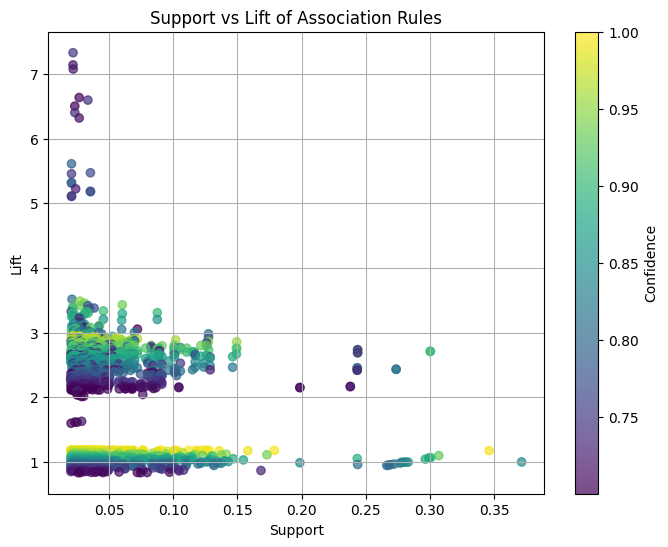

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    rules['support'],
    rules['lift'],
    c=rules['confidence'],
    alpha=0.7
)

plt.xlabel('Support')
plt.ylabel('Lift')
plt.title('Support vs Lift of Association Rules')

cbar = plt.colorbar(scatter)
cbar.set_label('Confidence')

plt.grid(True)
plt.show()


In [ ]:
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

rule_labels = [
    f"{list(a)} → {list(c)}"
    for a, c in zip(top_rules['antecedents'], top_rules['consequents'])
]


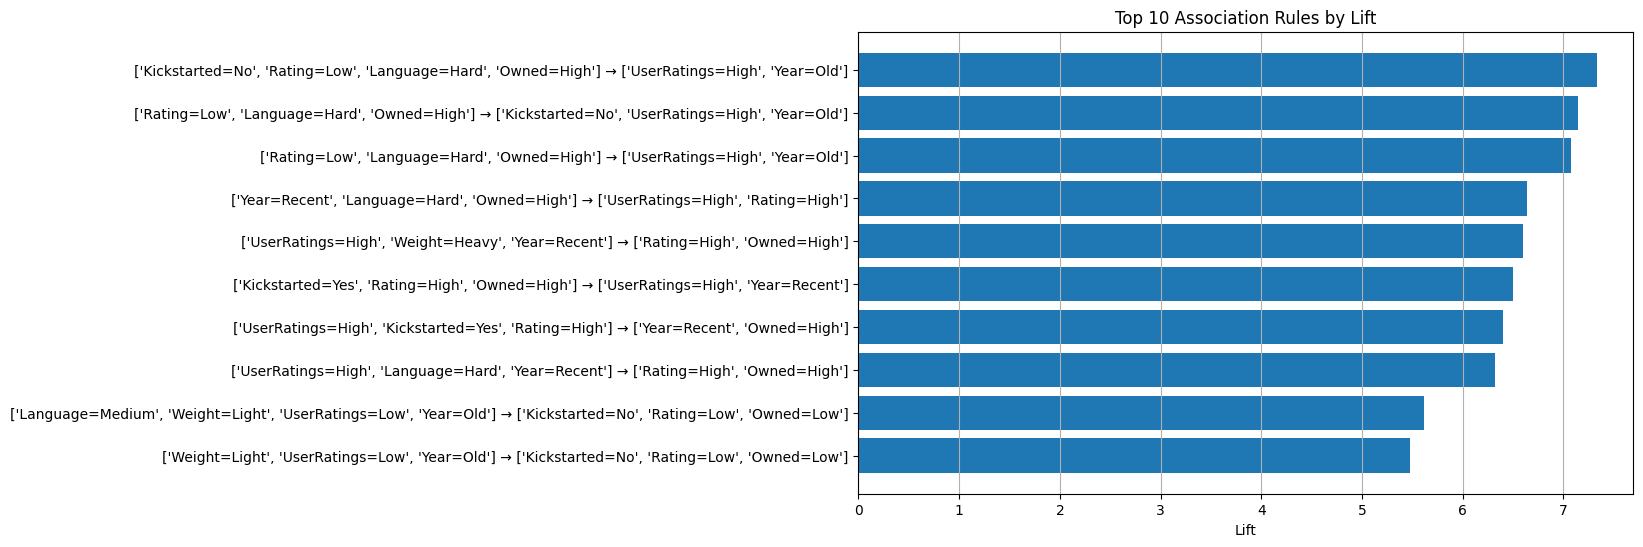

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(rule_labels, top_rules['lift'])
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')

plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.show()


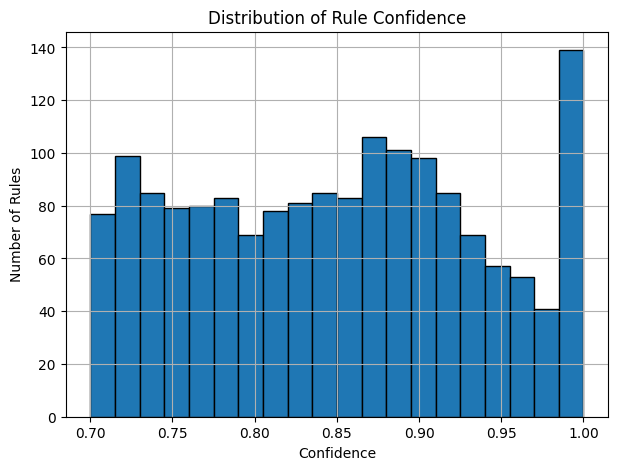

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(rules['confidence'], bins=20, edgecolor='black')

plt.xlabel('Confidence')
plt.ylabel('Number of Rules')
plt.title('Distribution of Rule Confidence')

plt.grid(True)
plt.show()


# Defining strong rules

In [ ]:
print("Total rules:", len(rules))
rules.head()


Total rules: 1648


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1502,"(Kickstarted=No, Rating=Low, Language=Hard, Ow...","(UserRatings=High, Year=Old)",0.029190,0.102121,0.021847,0.748437,7.328938,1.0,0.018866,3.569209,0.889520,0.199583,0.719826,0.481186
1507,"(Rating=Low, Language=Hard, Owned=High)","(Kickstarted=No, UserRatings=High, Year=Old)",0.030422,0.100570,0.021847,0.718141,7.140698,1.0,0.018788,3.191062,0.886940,0.200167,0.686625,0.467687
1491,"(Rating=Low, Language=Hard, Owned=High)","(UserRatings=High, Year=Old)",0.030422,0.102121,0.021984,0.722639,7.076308,1.0,0.018877,3.237218,0.885626,0.198845,0.691093,0.468957
1183,"(Year=Recent, Language=Hard, Owned=High)","(UserRatings=High, Rating=High)",0.037902,0.105906,0.026636,0.702768,6.635738,1.0,0.022622,3.008064,0.882759,0.227326,0.667560,0.477138
850,"(UserRatings=High, Weight=Heavy, Year=Recent)","(Rating=High, Owned=High)",0.044971,0.112702,0.033432,0.743408,6.596202,1.0,0.028364,3.458006,0.888348,0.269090,0.710816,0.520024


6.1 Set thresholds (start reasonable)

In [ ]:
MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.70
MIN_LIFT = 1.5


Filter strong rules

In [ ]:
strong_rules = rules[
    (rules["support"] >= MIN_SUPPORT) &
    (rules["confidence"] >= MIN_CONFIDENCE) &
    (rules["lift"] >= MIN_LIFT)
].copy()

print("Strong rules:", len(strong_rules))
strong_rules[["antecedents","consequents","support","confidence","lift"]].head(10)


Strong rules: 977


,antecedents,consequents,support,confidence,lift
1502,"(Kickstarted=No, Rating=Low, Language=Hard, Ow...","(UserRatings=High, Year=Old)",0.021847,0.748437,7.328938
1507,"(Rating=Low, Language=Hard, Owned=High)","(Kickstarted=No, UserRatings=High, Year=Old)",0.021847,0.718141,7.140698
1491,"(Rating=Low, Language=Hard, Owned=High)","(UserRatings=High, Year=Old)",0.021984,0.722639,7.076308
1183,"(Year=Recent, Language=Hard, Owned=High)","(UserRatings=High, Rating=High)",0.026636,0.702768,6.635738
850,"(UserRatings=High, Weight=Heavy, Year=Recent)","(Rating=High, Owned=High)",0.033432,0.743408,6.596202
1385,"(Kickstarted=Yes, Rating=High, Owned=High)","(UserRatings=High, Year=Recent)",0.023216,0.701102,6.502394
1386,"(UserRatings=High, Kickstarted=Yes, Rating=High)","(Year=Recent, Owned=High)",0.023216,0.739826,6.403741
1185,"(UserRatings=High, Language=Hard, Year=Recent)","(Rating=High, Owned=High)",0.026636,0.712195,6.319255
1598,"(Language=Medium, Weight=Light, UserRatings=Lo...","(Kickstarted=No, Rating=Low, Owned=Low)",0.020661,0.793345,5.610997
793,"(Weight=Light, UserRatings=Low, Year=Old)","(Kickstarted=No, Rating=Low, Owned=Low)",0.035393,0.773679,5.471907


6.3 Sort and inspect top strong rules

In [ ]:
strong_rules_sorted = strong_rules.sort_values(by=["lift","confidence"], ascending=False)

strong_rules_sorted[["antecedents","consequents","support","confidence","lift"]].head(10)


,antecedents,consequents,support,confidence,lift
1502,"(Kickstarted=No, Rating=Low, Language=Hard, Ow...","(UserRatings=High, Year=Old)",0.021847,0.748437,7.328938
1507,"(Rating=Low, Language=Hard, Owned=High)","(Kickstarted=No, UserRatings=High, Year=Old)",0.021847,0.718141,7.140698
1491,"(Rating=Low, Language=Hard, Owned=High)","(UserRatings=High, Year=Old)",0.021984,0.722639,7.076308
1183,"(Year=Recent, Language=Hard, Owned=High)","(UserRatings=High, Rating=High)",0.026636,0.702768,6.635738
850,"(UserRatings=High, Weight=Heavy, Year=Recent)","(Rating=High, Owned=High)",0.033432,0.743408,6.596202
1385,"(Kickstarted=Yes, Rating=High, Owned=High)","(UserRatings=High, Year=Recent)",0.023216,0.701102,6.502394
1386,"(UserRatings=High, Kickstarted=Yes, Rating=High)","(Year=Recent, Owned=High)",0.023216,0.739826,6.403741
1185,"(UserRatings=High, Language=Hard, Year=Recent)","(Rating=High, Owned=High)",0.026636,0.712195,6.319255
1598,"(Language=Medium, Weight=Light, UserRatings=Lo...","(Kickstarted=No, Rating=Low, Owned=Low)",0.020661,0.793345,5.610997
793,"(Weight=Light, UserRatings=Low, Year=Old)","(Kickstarted=No, Rating=Low, Owned=Low)",0.035393,0.773679,5.471907


6.4 (Important) Plot strong rules scatter (Support vs Lift, color=Confidence)

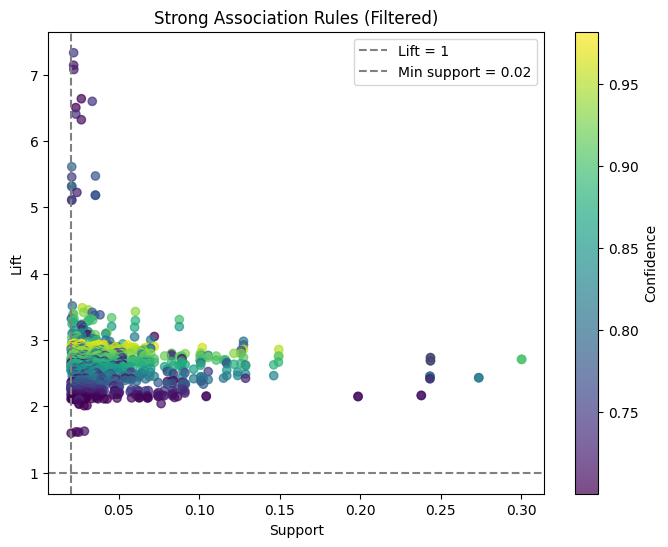

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    strong_rules["support"],
    strong_rules["lift"],
    c=strong_rules["confidence"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Confidence")
plt.axhline(y=1, linestyle="--", color="gray", label="Lift = 1")
plt.axvline(x=MIN_SUPPORT, linestyle="--", color="gray", label=f"Min support = {MIN_SUPPORT}")

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Strong Association Rules (Filtered)")
plt.legend()
plt.show()


Top 10 strong rules

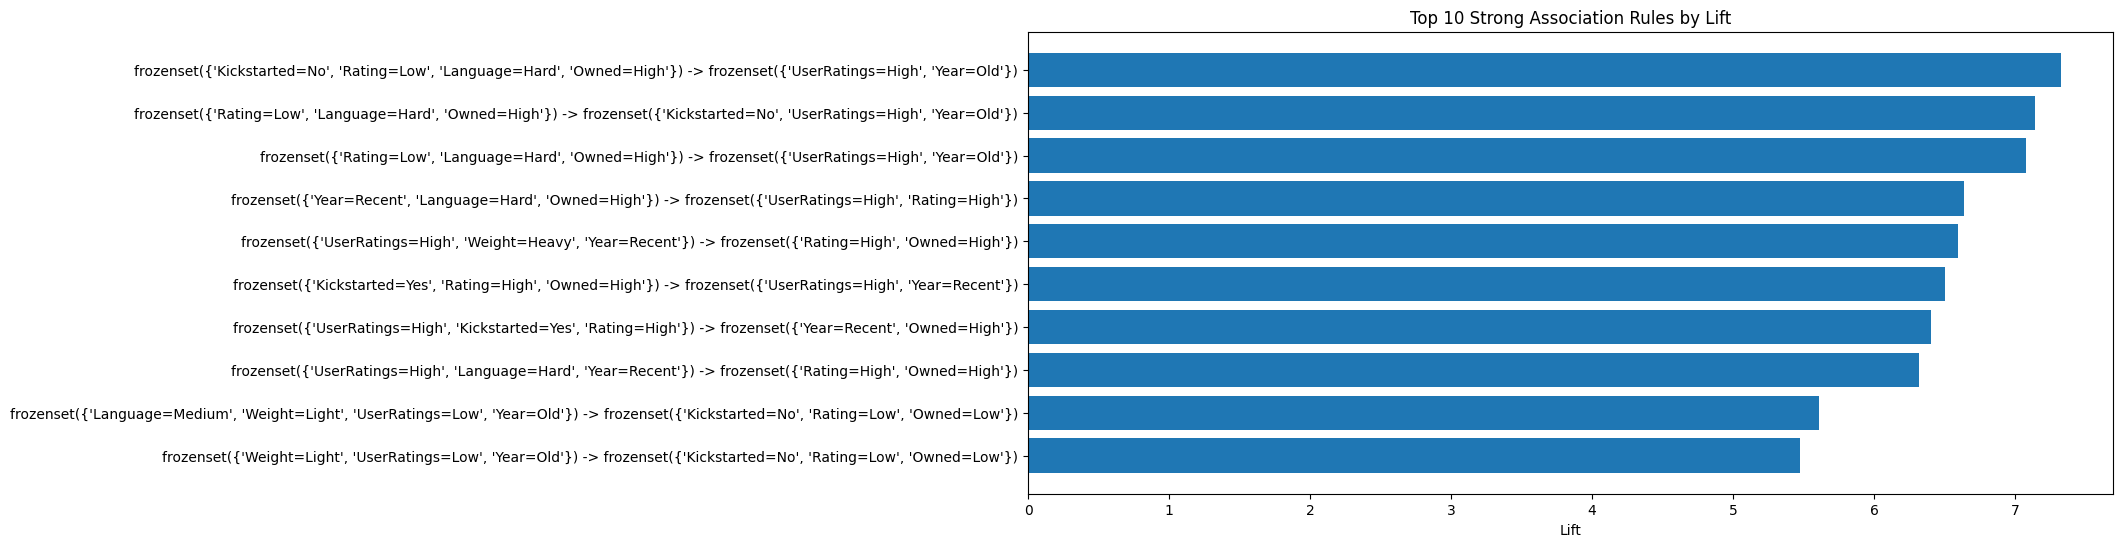

In [ ]:
top10 = strong_rules_sorted.head(10).copy()

top10["rule"] = top10["antecedents"].astype(str) + " -> " + top10["consequents"].astype(str)

plt.figure(figsize=(14,6))
plt.barh(top10["rule"][::-1], top10["lift"][::-1])
plt.xlabel("Lift")
plt.title("Top 10 Strong Association Rules by Lift")
plt.show()


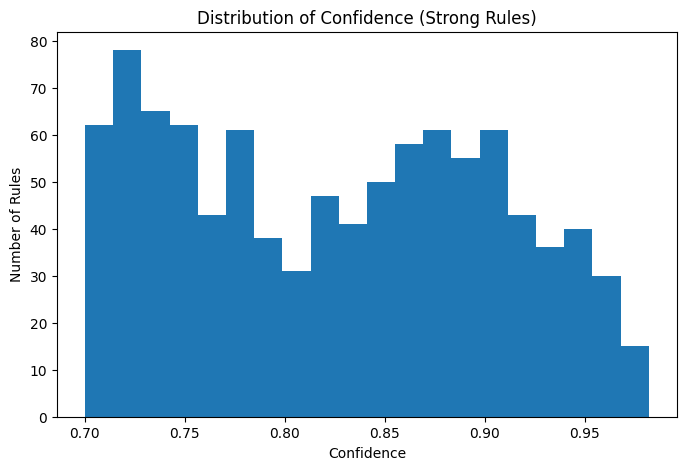

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(strong_rules["confidence"], bins=20)
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.title("Distribution of Confidence (Strong Rules)")
plt.show()


Seperation based on rating

In [ ]:
low_rules = rating_rules[rating_rules["consequents"].astype(str).str.contains("Rating=Low")]
med_rules = rating_rules[rating_rules["consequents"].astype(str).str.contains("Rating=Medium")]
high_rules = rating_rules[rating_rules["consequents"].astype(str).str.contains("Rating=High")]

print("Low rules:", len(low_rules))
print("Medium rules:", len(med_rules))
print("High rules:", len(high_rules))

low_rules[["antecedents","consequents","support","confidence","lift"]].head(5)


Low rules: 47
Medium rules: 4
High rules: 13


,antecedents,consequents,support,confidence,lift
1598,"(Language=Medium, Weight=Light, UserRatings=Lo...","(Kickstarted=No, Rating=Low, Owned=Low)",0.020661,0.793345,5.610997
793,"(Weight=Light, UserRatings=Low, Year=Old)","(Kickstarted=No, Rating=Low, Owned=Low)",0.035393,0.773679,5.471907
1597,"(Language=Medium, Owned=Low, Weight=Light, Yea...","(Kickstarted=No, Rating=Low, UserRatings=Low)",0.020661,0.750000,5.455790
1593,"(Kickstarted=No, Language=Medium, Weight=Light...","(Rating=Low, Owned=Low)",0.020661,0.794737,5.320490
1603,"(Language=Medium, Weight=Light, UserRatings=Lo...","(Rating=Low, Owned=Low)",0.020661,0.793345,5.311172


# Changing threshold

In [ ]:
MIN_SUPPORT    = 0.05   # at least 5% of games
MIN_CONFIDENCE = 0.80   # more reliable rules
MIN_LIFT       = 2.5    # clearly non-random


In [ ]:
strong_rules_tight = rules[
    (rules["support"] >= MIN_SUPPORT) &
    (rules["confidence"] >= MIN_CONFIDENCE) &
    (rules["lift"] >= MIN_LIFT)
].copy()

print("Strong rules (tight):", len(strong_rules_tight))

strong_rules_tight[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)


Strong rules (tight): 125


,antecedents,consequents,support,confidence,lift
366,"(Language=Hard, Owned=High, Year=Old)","(Kickstarted=No, UserRatings=High)",0.060251,0.933569,3.429134
206,"(Owned=High, Year=Old)","(Kickstarted=No, UserRatings=High)",0.087526,0.900516,3.307726
367,"(UserRatings=High, Language=Hard, Year=Old)","(Kickstarted=No, Owned=High)",0.060251,0.881254,3.292128
205,"(UserRatings=High, Year=Old)","(Kickstarted=No, Owned=High)",0.087526,0.857079,3.201816
372,"(Language=Hard, Rating=Medium, Owned=High)","(Kickstarted=No, UserRatings=High)",0.059749,0.868700,3.190862
373,"(UserRatings=High, Language=Hard, Rating=Medium)","(Kickstarted=No, Owned=High)",0.059749,0.815691,3.047202
286,"(Weight=Light, Owned=High)","(Kickstarted=No, UserRatings=High)",0.069738,0.817210,3.001731
69,"(Language=Hard, Owned=High)","(Kickstarted=No, UserRatings=High)",0.127434,0.811502,2.980763
432,"(Language=Medium, Owned=Low, Year=Old)","(Kickstarted=No, UserRatings=Low)",0.052452,0.871873,2.941346
408,"(UserRatings=High, Language=Hard, Rating=High)",(Owned=High),0.055507,0.975160,2.928018


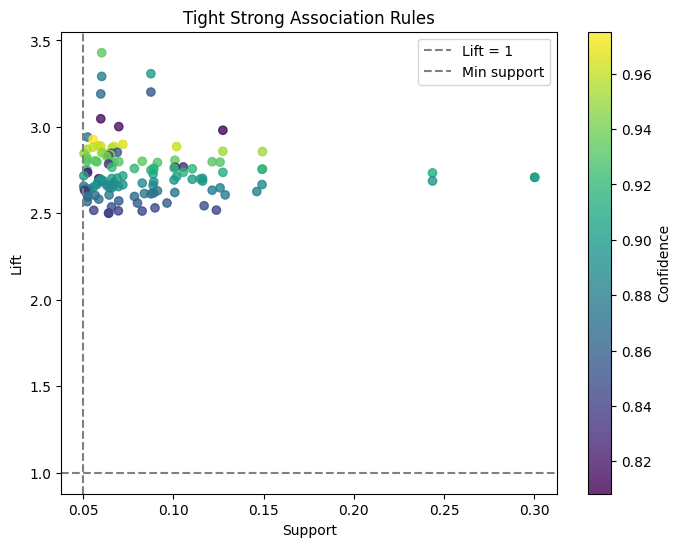

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    strong_rules_tight["support"],
    strong_rules_tight["lift"],
    c=strong_rules_tight["confidence"],
    cmap="viridis",
    alpha=0.8
)

plt.colorbar(label="Confidence")

plt.axhline(y=1, linestyle="--", color="gray", label="Lift = 1")
plt.axvline(x=MIN_SUPPORT, linestyle="--", color="gray", label="Min support")

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Tight Strong Association Rules")
plt.legend()
plt.show()


In [ ]:
top_rules = strong_rules_tight.sort_values(
    by="lift", ascending=False
).head(10)

top_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]


,antecedents,consequents,support,confidence,lift
366,"(Language=Hard, Owned=High, Year=Old)","(Kickstarted=No, UserRatings=High)",0.060251,0.933569,3.429134
206,"(Owned=High, Year=Old)","(Kickstarted=No, UserRatings=High)",0.087526,0.900516,3.307726
367,"(UserRatings=High, Language=Hard, Year=Old)","(Kickstarted=No, Owned=High)",0.060251,0.881254,3.292128
205,"(UserRatings=High, Year=Old)","(Kickstarted=No, Owned=High)",0.087526,0.857079,3.201816
372,"(Language=Hard, Rating=Medium, Owned=High)","(Kickstarted=No, UserRatings=High)",0.059749,0.868700,3.190862
373,"(UserRatings=High, Language=Hard, Rating=Medium)","(Kickstarted=No, Owned=High)",0.059749,0.815691,3.047202
286,"(Weight=Light, Owned=High)","(Kickstarted=No, UserRatings=High)",0.069738,0.817210,3.001731
69,"(Language=Hard, Owned=High)","(Kickstarted=No, UserRatings=High)",0.127434,0.811502,2.980763
432,"(Language=Medium, Owned=Low, Year=Old)","(Kickstarted=No, UserRatings=Low)",0.052452,0.871873,2.941346
408,"(UserRatings=High, Language=Hard, Rating=High)",(Owned=High),0.055507,0.975160,2.928018


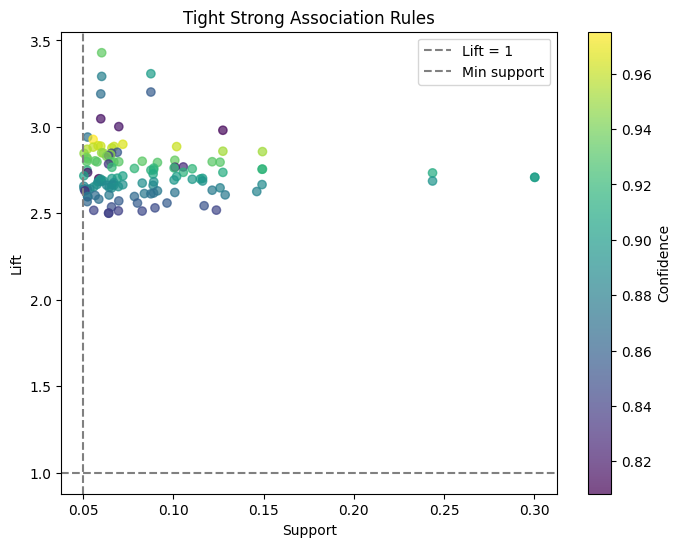

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    strong_rules_tight["support"],
    strong_rules_tight["lift"],
    c=strong_rules_tight["confidence"],
    cmap="viridis",
    alpha=0.7
)

# Reference lines
plt.axhline(y=1, linestyle="--", color="gray", label="Lift = 1")
plt.axvline(x=MIN_SUPPORT, linestyle="--", color="gray", label="Min support")

plt.colorbar(label="Confidence")
plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Tight Strong Association Rules")
plt.legend()
plt.show()


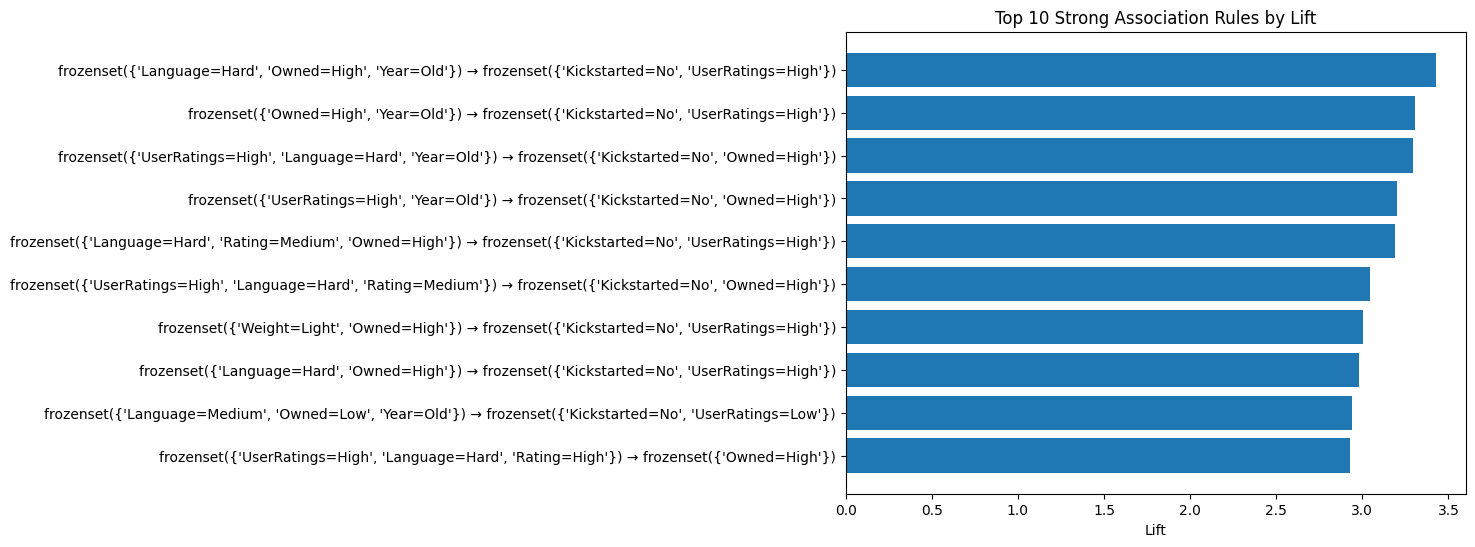

In [ ]:
top_rules = strong_rules_tight.sort_values(
    by="lift", ascending=False
).head(10)

plt.figure(figsize=(8, 6))
plt.barh(
    top_rules["antecedents"].astype(str) + " → " +
    top_rules["consequents"].astype(str),
    top_rules["lift"]
)
plt.xlabel("Lift")
plt.title("Top 10 Strong Association Rules by Lift")
plt.gca().invert_yaxis()
plt.show()
